## Lab 02 - ANN DL - MLP (Multi-Layered Perceptron) for Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import make_regression
from sklearn import metrics
from sklearn import decomposition
from sklearn import manifold
from tqdm.notebook import trange, tqdm

#TensorFlow and Keras Libraries
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model
import torch
from torchvision import transforms
from tensorflow.keras.utils import to_categorical
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# Hiding the warnings
import warnings
warnings.filterwarnings('ignore')

# Extra Libraries
import copy
import random
import time

# Linkl to the dataset : https://github.com/ywchiu/riii/blob/master/data/house-prices.csv

In [2]:
# Loading Data For Regression :
data_path = "DataBase/Reg_Data/Uni_Variate_Linear_Regression.csv"
df = pd.read_csv(data_path)

In [3]:
df.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
x,700.0,54.985939,134.681703,0.000000,25.000000,49.00000,75.000000,3530.157369
y,699.0,49.939869,29.109217,-3.839981,24.929968,48.97302,74.929911,108.871618


In [6]:
df.shape

(700, 2)

In [7]:
# Missing Values :
df.dropna(inplace=True)
df.isna().sum()

x    0
y    0
dtype: int64

In [8]:
# Data Redundancy :
df.duplicated().sum()

np.int64(0)

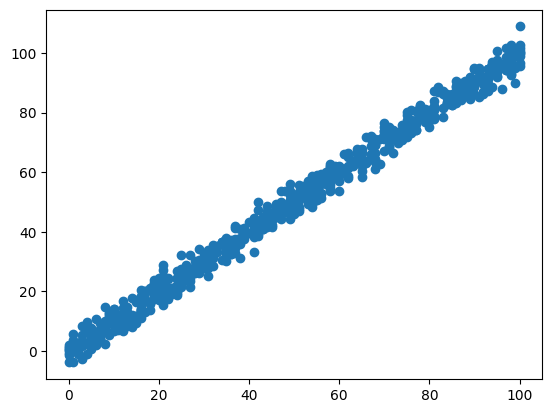

In [9]:
# Visualizing the X and y :
plt.scatter(df['x'], df['y'])
plt.show()

In [10]:
# Train - Test Split : 
X_train, X_test, y_train, y_test = train_test_split(df['x'],df['y'],test_size=0.3,random_state=42)
print("X_Train Shape : ",X_train.shape)
print("X_Test Shape : ",X_test.shape)
print("y_train Shape : ",y_train.shape)
print("y_test Shape : ",y_test.shape)

X_Train Shape :  (489,)
X_Test Shape :  (210,)
y_train Shape :  (489,)
y_test Shape :  (210,)


In [11]:
# Creating an MLP model :
# Keras Model ->
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(62, activation='relu', input_dim=1))
model.add(tf.keras.layers.Dense(62, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))

In [12]:
model.compile(loss='mse', optimizer='adam', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=500)

Epoch 1/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1935.5376 - mae: 37.7893  
Epoch 2/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 106.5360 - mae: 7.7214  
Epoch 3/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 50.9749 - mae: 6.0494 
Epoch 4/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.2928 - mae: 2.3844  
Epoch 5/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.5988 - mae: 2.4775  
Epoch 6/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.6912 - mae: 2.1543 
Epoch 7/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.0671 - mae: 2.2330 
Epoch 8/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.8773 - mae: 2.1850 
Epoch 9/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.0869 - mae: 2.2255 
Epoch 10/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.8860 - mae: 2.3039  
Epoch 11/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1594 - mae: 2.2965 
Epoch 12/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.4273 - mae: 2.1408 
Epoch 13/500


In [13]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [14]:
# Now for the regression we will calculate the R2_Score and MSE Score :
print("R2_Score : ",r2_score(y_test,y_pred))
print("MSE Score : ",mean_squared_error(y_test,y_pred))

R2_Score :  0.990995525702075
MSE Score :  7.81683814435693


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


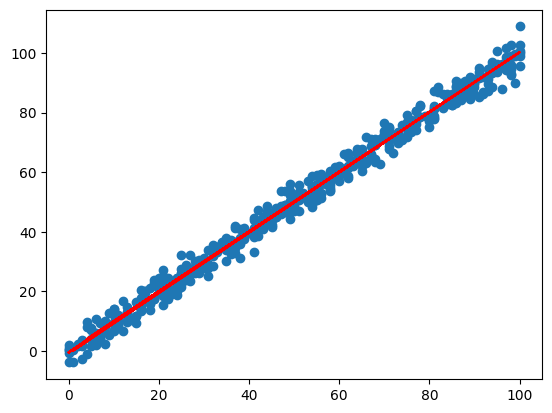

In [15]:
# Visualizing the data with the line (model) :
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train), color='red')
plt.show()

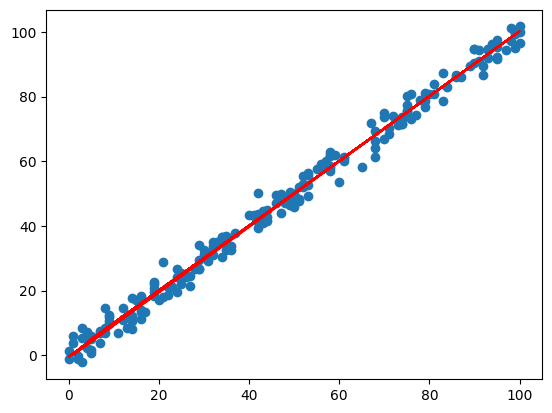

In [16]:
# Visualizing the data with the line (model) :
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.show()

### MLP for Multi-Variate data :

In [17]:
path_new_data = "DataBase/Reg_Data/CarPrice_Assignment.csv"
df2 = pd.read_csv(path_new_data)

In [18]:
df2.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [19]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [20]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
car_ID,205.0,103.000000,59.322565,1.00,52.00,103.00,154.00,205.00
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
enginesize,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17


In [21]:
df2.shape

(205, 26)

In [22]:
# Checking Missing values :
df2.isna().sum().sum()

np.int64(0)

In [23]:
df2.duplicated().sum()

np.int64(0)

In [24]:
df2.drop('car_ID',axis=1,inplace=True)

In [25]:
# Visualizing the X and y :
#sns.pairplot(df2,kind='reg')

In [26]:
# Implementing Label Encoding to the object type columns :
for i in df2.columns:
    if df2[i].dtype == 'O':
        le = LabelEncoder()
        df2[i] = le.fit_transform(df2[i])

In [27]:
# Train - Test Split : 
X = df2.drop('price',axis=1)
y = df2['price']
X_train, X_test, y_train, y_test = train_test_split(X ,y ,test_size=0.3,random_state=42)
print("X_Train Shape : ",X_train.shape)
print("X_Test Shape : ",X_test.shape)
print("y_train Shape : ",y_train.shape)
print("y_test Shape : ",y_test.shape)

X_Train Shape :  (143, 24)
X_Test Shape :  (62, 24)
y_train Shape :  (143,)
y_test Shape :  (62,)


In [28]:
# Creating an MLP model :
# Keras Model ->
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(62, activation='relu', input_dim=24))
model.add(tf.keras.layers.Dense(62, activation='relu'))
model.add(tf.keras.layers.Dense(62, activation='relu'))
model.add(tf.keras.layers.Dense(62, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))

In [29]:
model.compile(loss='mse', optimizer='adam', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 216476208.0000 - mae: 12696.7148
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 196605088.0000 - mae: 11593.3047 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 177758976.0000 - mae: 10916.6006 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 140132848.0000 - mae: 8934.9316 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 112492752.0000 - mae: 7072.5039 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 71864720.0000 - mae: 5562.0464
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 59729112.0000 - mae: 5753.8325 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 53759308.0000 - mae: 5926.0796 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 54289828.0000 - mae: 5952.2368 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 46510716.0000 - mae: 5357.2334 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 57823180.0000 - mae: 5483.5195 
Epoc

In [30]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


In [31]:
# Now for the regression we will calculate the R2_Score and MSE Score :
print("R2_Score : ",r2_score(y_test,y_pred))
print("RMSE Score : ",mean_squared_error(y_test,y_pred)**0.5)

R2_Score :  0.8477139760610244
RMSE Score :  3248.2368355454073
